In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 0. 全局美学设置 (Publication Style)
# ==========================================
def set_pub_style():
    sns.set_theme(style="white", context="talk") # context="talk" 会自动把字体调大，适合PPT
    plt.rcParams['font.family'] = 'sans-serif'   # 英文可以用 sans-serif，中文需另外指定字体
    plt.rcParams['axes.edgecolor'] = '#333333'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['grid.color'] = '#dddddd'
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.6

class ModelEvaluator:
    def __init__(self, model_dict):
        """
        初始化评估器，自动处理不等长数据
        """
        set_pub_style()
        self.raw_dict = model_dict
        self.models = list(model_dict.keys())
        self.n_models = len(self.models)
        
        # 转换为长格式 DataFrame
        dfs = []
        for name, values in model_dict.items():
            vals = np.array(values).flatten()
            dfs.append(pd.DataFrame({'MSE': vals, 'Model': name}))
        self.df = pd.concat(dfs, ignore_index=True)
        
        # 预计算统计指标
        self.stats = self.df.groupby('Model')['MSE'].agg([
            ('Count', 'count'),
            ('Mean', 'mean'),
            ('Best', 'min'),
            ('Top_5', lambda x: np.percentile(x, 5)),
            ('Top_25', lambda x: np.percentile(x, 25)),
            ('Median', 'median'),
            ('Risk_95', lambda x: np.percentile(x, 95)),
            ('Std', 'std')
        ])

        self.stats = self.stats.round(4)
        
        # 定义专属配色 (只要模型顺序不变，颜色就固定)
        self.palette = sns.color_palette("deep", n_colors=self.n_models)
        self.color_map = dict(zip(self.models, self.palette))

    # ==========================================
    # 图表 1: 风险-收益气泡图 (Risk-Reward Bubble)
    # ==========================================
    def plot_risk_reward(self, save_path=None):
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # 提取数据
        x = self.stats['Risk_95']
        y = self.stats['Median']
        sizes = self.stats['Count']
        
        # 归一化气泡大小 (最小300，最大1000)
        norm_sizes = 300 + (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-8) * 700
        
        # 绘制
        for i, model in enumerate(self.models):
            ax.scatter(x[model], y[model], s=norm_sizes[model], 
                       color=self.color_map[model], alpha=0.8, 
                       edgecolors='white', linewidth=2, label=model)
            
            # 添加文字标签 (带一点偏移防止重叠)
            ax.text(x[model], y[model], f" {model}", 
                    fontsize=12, fontweight='bold', color='#333333',
                    verticalalignment='bottom', horizontalalignment='left')

        # 美化轴
        ax.set_title("Risk vs. Reward Landscape", fontsize=18, pad=20, fontweight='bold')
        ax.set_xlabel("Tail Risk (95th Percentile MSE)", fontsize=14, labelpad=10)
        ax.set_ylabel("Typical Performance (Median MSE)", fontsize=14, labelpad=10)
        
        # 绘制理想区域指示箭头
        ax.annotate('Ideal Zone\n(Stable & Accurate)', 
                    xy=(x.min(), y.min()), xytext=(x.min(), y.min()*1.1),
                    arrowprops=dict(facecolor='#444444', shrink=0.05, alpha=0.6),
                    fontsize=11, color='#444444')
        
        ax.grid(True)
        sns.despine(trim=True) # 去除上方和右方的边框
        
        if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # ==========================================
    # 图表 2: 胜率热力图 (Win-Rate Heatmap)
    # ==========================================
    def plot_win_rate(self, save_path=None):
        fig, ax = plt.subplots(figsize=(9, 8))
        
        win_matrix = pd.DataFrame(index=self.models, columns=self.models, dtype=float)
        n_sample = 5000
        
        for m1 in self.models:
            for m2 in self.models:
                if m1 == m2: 
                    win_matrix.loc[m1, m2] = 0.5
                else:
                    v1 = np.random.choice(self.raw_dict[m1], n_sample, replace=True)
                    v2 = np.random.choice(self.raw_dict[m2], n_sample, replace=True)
                    win_matrix.loc[m1, m2] = np.mean(v1 < v2)

        # 使用红蓝配色 (RdBu_r)，红色代表高胜率，蓝色代表低胜率，白色由0.5居中
        sns.heatmap(win_matrix, annot=True, fmt=".1%", cmap="RdBu_r", 
                    center=0.5, vmin=0.3, vmax=0.7,
                    square=True, cbar_kws={"shrink": .8, "label": "Win Probability"},
                    linewidths=1, linecolor='white', ax=ax)
        
        ax.set_title("Head-to-Head Win Rate Matrix", fontsize=18, pad=20, fontweight='bold')
        ax.set_ylabel("Model A (Candidate)", fontsize=14)
        ax.set_xlabel("Model B (Opponent)", fontsize=14)
        
        if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # ==========================================
    # 图表 3: 累积分布图 (ECDF) - 极简线条
    # ==========================================
    def plot_ecdf(self, save_path=None):
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # 1. 画图 (Seaborn 会自动生成默认图例)
        sns.ecdfplot(data=self.df, x='MSE', hue='Model', 
                    palette=self.palette, linewidth=3, alpha=0.9, ax=ax)
        
        # 2. 截断长尾
        p98 = self.df['MSE'].quantile(0.98)
        ax.set_xlim(0, p98)
        
        # 3. 设置标题和标签
        ax.set_title("ECDF: Accuracy Dominance Analysis", fontsize=18, pad=20, fontweight='bold')
        ax.set_xlabel("MSE Threshold", fontsize=14)
        ax.set_ylabel("Cumulative Probability", fontsize=14)
        
        # 4. 【关键修改】使用 move_legend 修改图例，而不是调用 ax.legend()
        # 这既改变了位置，又保留了 Seaborn 的 hue 映射信息
        try:
            sns.move_legend(ax, "lower right", frameon=False, fontsize=12, title=None)
        except AttributeError:
            # 如果 Seaborn 版本过老不支持 move_legend，使用备用方案
            # 显式获取 Seaborn 画出的线条和标签
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(handles, labels, frameon=False, loc='lower right', fontsize=12)
        
        ax.grid(True, alpha=0.4)
        sns.despine()
        
        if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # ==========================================
    # 图表 4: 手风琴图 (Ridgeline) - 艺术感最强
    # ==========================================
    def plot_ridgeline(self, save_path=None):
        # 创建一个专用的 Figure
        fig, ax = plt.subplots(figsize=(10, 8))
        
        models_rev = list(reversed(self.models))
        pal_rev = list(reversed(self.palette))
        
        x_grid = np.linspace(self.df['MSE'].min(), self.df['MSE'].quantile(0.98), 500)
        overlap = 0.7 # 增加重叠度，更有艺术感
        
        for i, model in enumerate(models_rev):
            z = len(models_rev) - i
            data = self.raw_dict[model]
            if len(data) < 2: continue
            
            kde = stats.gaussian_kde(data)
            y = kde(x_grid)
            y = y / y.max() # 归一化
            
            # 错位堆叠
            base = i * (1 - overlap)
            y_shifted = y + base
            
            # 填充颜色 + 白色描边 (制造层次感)
            ax.fill_between(x_grid, base, y_shifted, color=pal_rev[i], alpha=0.85, zorder=z+1)
            ax.plot(x_grid, y_shifted, color='white', linewidth=1.5, zorder=z+1)
            
            # 添加标签
            ax.text(x_grid[0], base + 0.15, model, 
                    fontweight='bold', fontsize=13, color=pal_rev[i], 
                    ha='right', va='center')

        # 彻底移除边框和Y轴，只保留底部的X轴
        ax.set_yticks([])
        sns.despine(left=True, bottom=False)
        ax.set_xlabel("MSE Distribution Density", fontsize=14)
        ax.set_title("Ridgeline Distribution Comparison", fontsize=18, pad=30, fontweight='bold')
        
        if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # ==========================================
    # 图表 5: 雨云图 (Box + Strip) - 数据洞察
    # ==========================================
    def plot_box_strip(self, save_path=None):
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # 箱线图：半透明，作为背景
        sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,
                    width=0.4, showfliers=False, ax=ax, boxprops=dict(alpha=0.6))
        
        # 散点图：展示真实分布密度
        # sample一下避免点太多卡顿
        display_df = self.df.sample(min(1000, len(self.df))) if len(self.df) > 1000 else self.df
        
        sns.stripplot(data=display_df, x='Model', y='MSE', color='#333333', 
                      size=3, alpha=0.4, jitter=0.2, ax=ax)
        
        ax.set_title("Distribution Spread & Outliers", fontsize=18, pad=20, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("MSE", fontsize=14)
        sns.despine(trim=True)
        
        if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

In [4]:
from collections import Counter

def filter_list_by_partial_duplicate(data_list, remove_index, sep="_"):
    """
    Args:
        data_list: 原始字符串列表
        remove_index: 需要移除的元素的索引
        sep: 分隔符，默认为 "_"
    Returns:
        过滤后的列表
    """
    # 步骤 1: 生成对比用的"签名" (Signature)
    # 我们需要保留原始字符串和签名的对应关系
    signatures = []
    
    for s in data_list:
        parts = s.split(sep)
        
        # 确保索引在有效范围内
        if 0 <= remove_index < len(parts):
            # 移除指定位置的元素
            # 使用切片组合比 pop 更安全，不会影响原列表
            new_parts = parts[:remove_index] + parts[remove_index+1:]
            
            # 根据你的例子 "A_B_C" -> "AC"，这里使用空字符串拼接
            # 如果你是想变成 "A_C"，则用 sep.join(new_parts)
            sig = "".join(new_parts) 
        else:
            sig = s # 索引越界时的兜底处理
            
        signatures.append(sig)

    # 步骤 2: 统计频率
    # 结果类似于 {'AC': 2, 'AD': 1}
    counts = Counter(signatures)

    # 步骤 3: 过滤
    # 如果对应的签名出现次数 > 1，则保留原始字符串
    result = []
    for original_str, sig in zip(data_list, signatures):
        if counts[sig] > 1:
            result.append(original_str)
            
    return result

In [5]:
# 按照组件选择对相关性矩阵进行分组分析
def get_component_name(modelpathlist, target_compoents):
    # 根据选定的组件名称，返回对应的modelid的dict
    result = {}
    compoents2idx = {
        "gym_x_mark":2,
        "gym_series_sampling":3,
        "gym_series_norm":4,
        "gym_series_decomp":5,
        "gym_channel_independent":6,
        "gym_input_embed":7,
        "gym_network_architecture":8,
        "gym_attn":9,
        "gym_feature_attn":10,
        "gym_seq_len":15,
        "loss_function":27
    }
    print(len(modelpathlist))
    modelpathlist = filter_list_by_partial_duplicate(modelpathlist, compoents2idx[target_compoents])
    print(len(modelpathlist))
    for modelpath in modelpathlist:
        modelname = modelpath.split("/")[-2]
        # print(modelname)
        model_components = modelname.split("_")[compoents2idx[target_compoents]]
        modelid = modelname.split("_")[1]
        metrics_value = np.load(modelpath)[1]
        result.setdefault(model_components, []).append(metrics_value)
    return result

In [6]:
# root_path = "/data/nishome/user1/chaochuan/TSGym_benchmark/results_long_term_forecasting/resultsGym_transformer/nyse"
# datapathlist = [os.path.join(root_path, f, 'metrics.npy') for f in os.listdir(root_path) if "pl24" in f]

root_path = "/data/nishome/user1/chaochuan/TSGym_benchmark/results_long_term_forecasting/resultsGym_non_transformer/nasdaq"
datapathlist = [os.path.join(root_path, f, 'metrics.npy') for f in os.listdir(root_path) if "pl24" in f]

In [7]:
dict_x_mark2mse = get_component_name(datapathlist, "gym_x_mark")


2044
0


In [5]:
dict_x_mark2mse = get_component_name(datapathlist, "gym_x_mark")
dict_seriessampling2mse = get_component_name(datapathlist, "gym_series_sampling")
dict_seriesnorm2mse = get_component_name(datapathlist, "gym_series_norm")
dict_seriesdecomp2mse = get_component_name(datapathlist, "gym_series_decomp")
dict_channelindependent2mse = get_component_name(datapathlist, "gym_channel_independent")
dict_inputembed2mse = get_component_name(datapathlist, "gym_input_embed")
dict_networkarchitecture2mse = get_component_name(datapathlist, "gym_network_architecture")
dict_attn2mse = get_component_name(datapathlist, "gym_attn")
dict_featureattn2mse = get_component_name(datapathlist, "gym_feature_attn")
dict_seqlen2mse = get_component_name(datapathlist, "gym_seq_len")
dict_lossfn2mse = get_component_name(datapathlist, "loss_function")


       Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                
GRU     1022  2.1916  0.4080  0.5224  0.7941  1.6506   5.8952  1.6879
MLP      984  2.1224  0.3701  0.4893  0.6921  1.4999   5.7887  1.7580
绘制手风琴图...


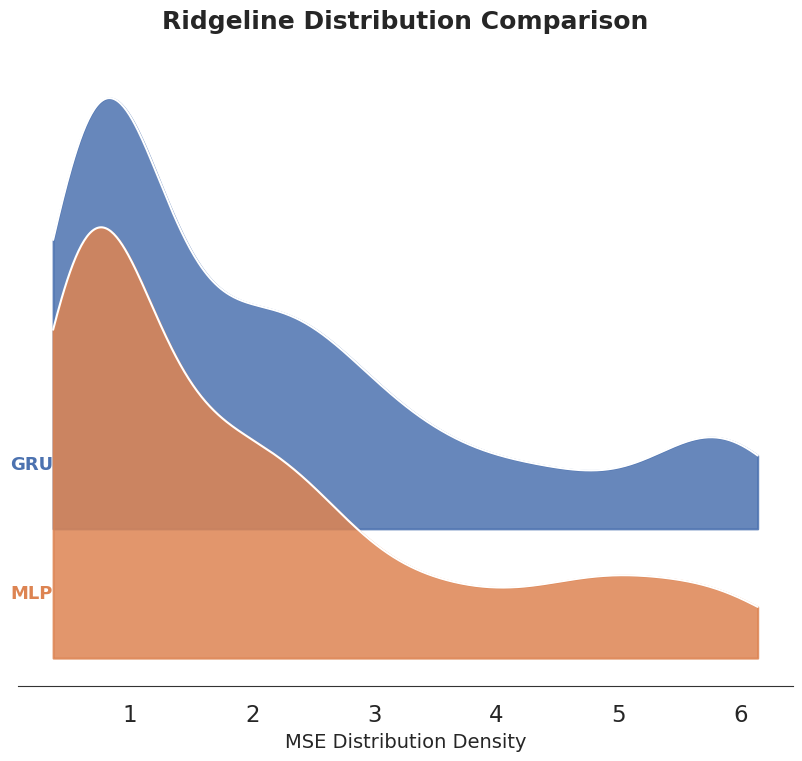

绘制ECDF图...


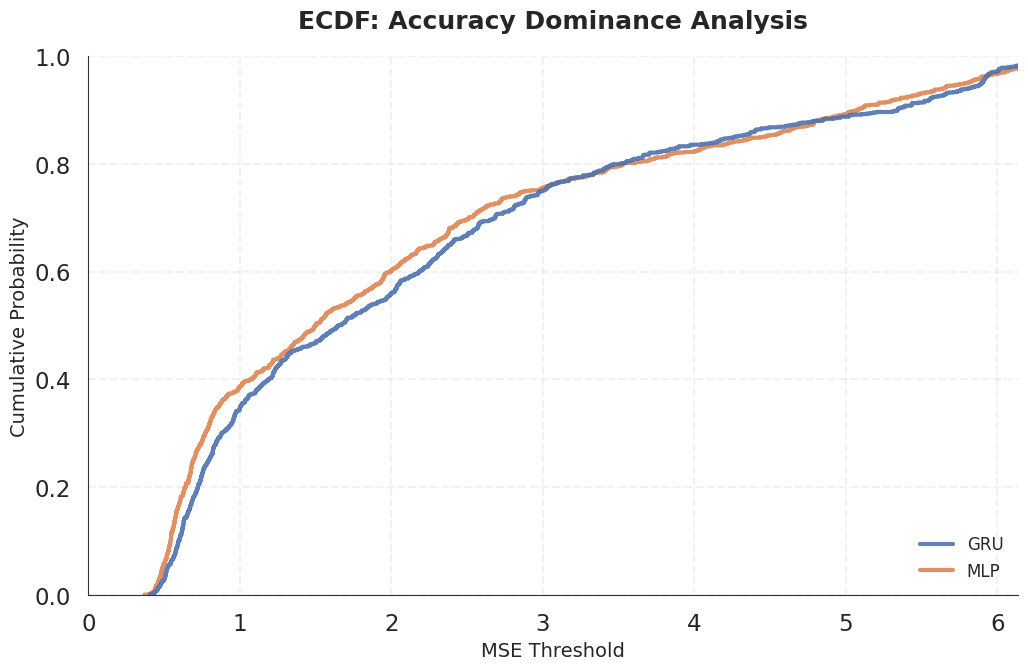

绘制箱线散点图...


/tmp/ipykernel_2642138/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


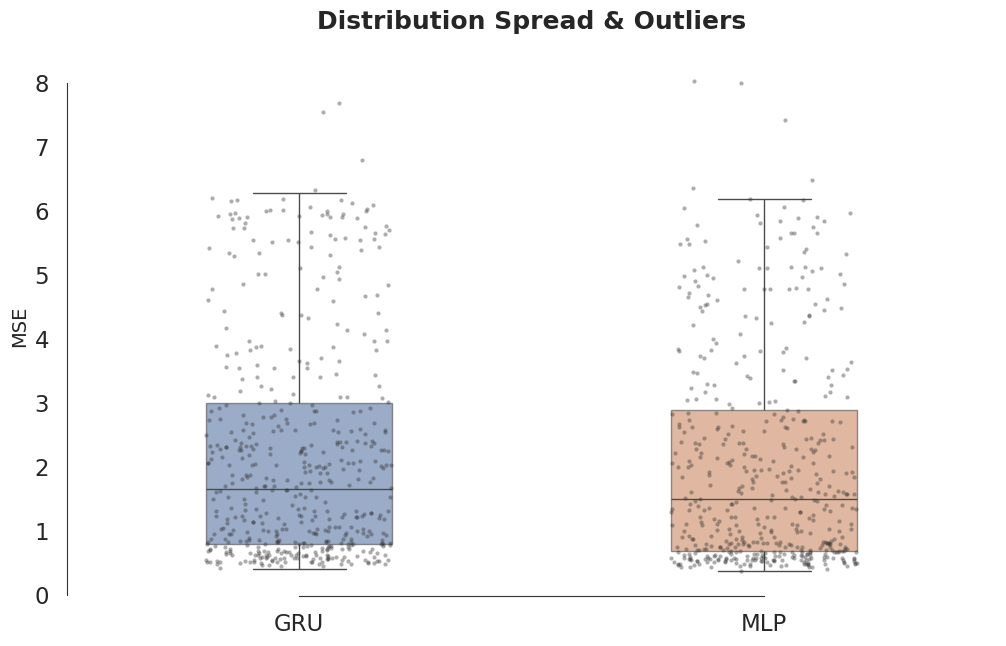

In [6]:
dict_networkarchitecture2mse = get_component_name(datapathlist, "gym_network_architecture")

evaluator = ModelEvaluator(dict_networkarchitecture2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

       Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                
False   1028  2.2732  0.3701  0.5095  0.7785  1.7053   5.9035  1.7774
True     978  2.0362  0.4152  0.5086  0.7139  1.4168   5.6478  1.6552
绘制手风琴图...


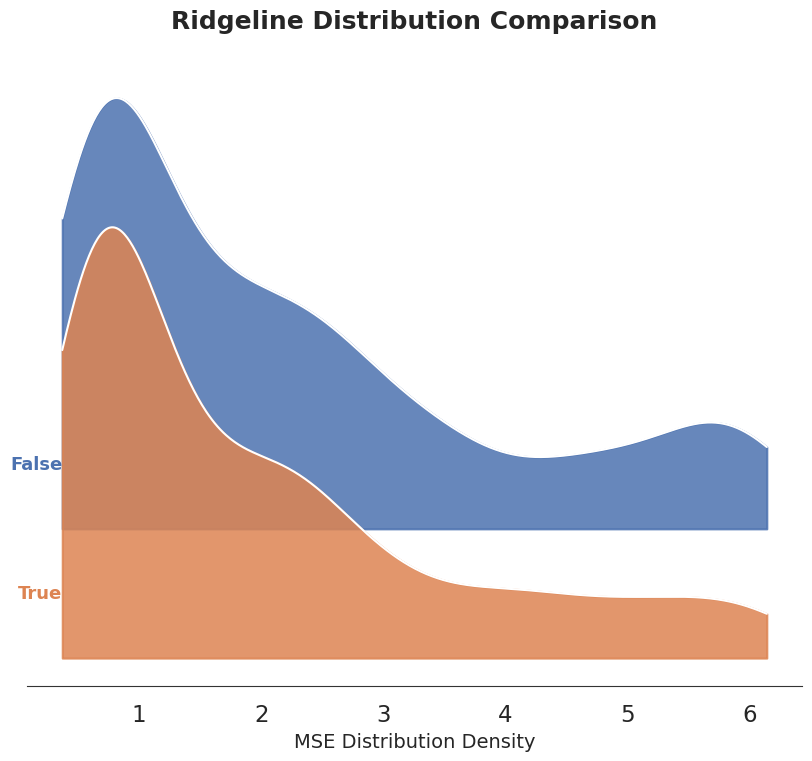

绘制ECDF图...


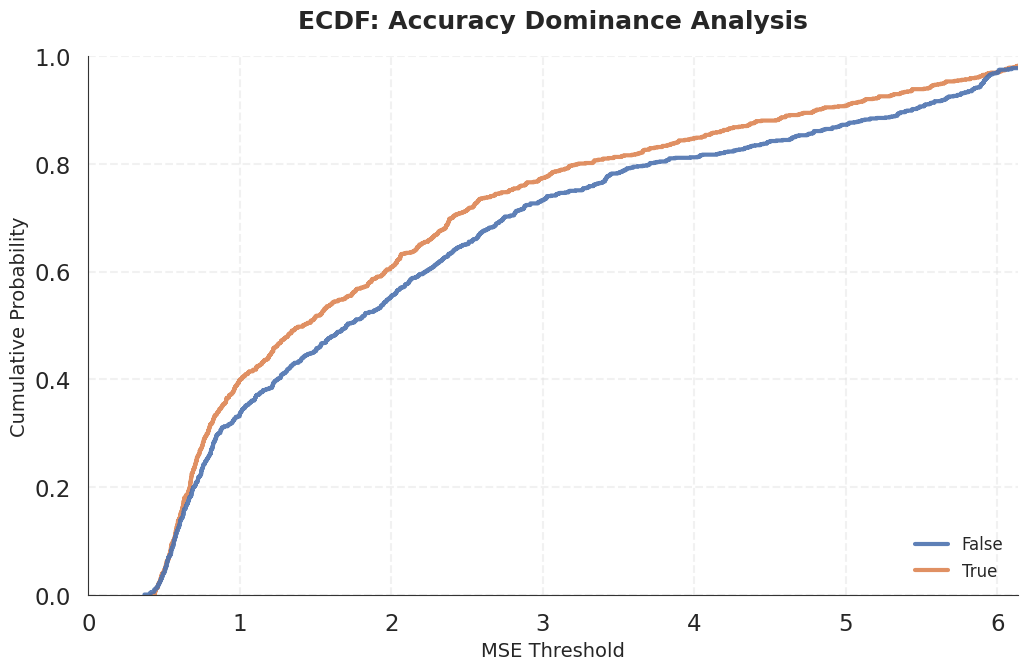

绘制箱线散点图...


/tmp/ipykernel_2642138/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


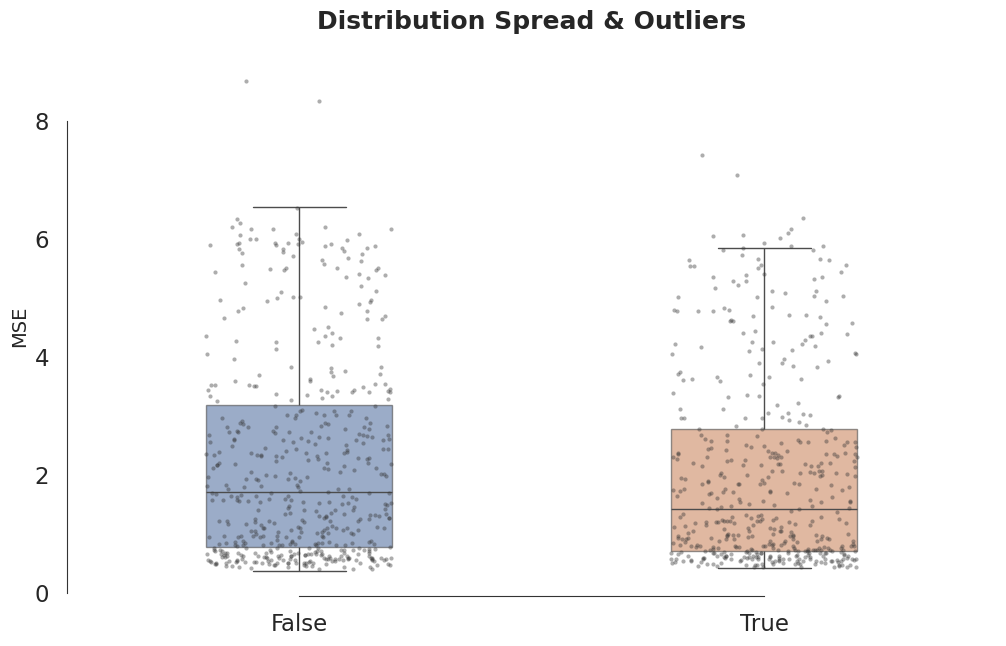

In [7]:
evaluator = ModelEvaluator(dict_x_mark2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

       Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                
False    946  2.1192  0.3701  0.4901  0.7238  1.5221   5.8860  1.7233
True    1060  2.1920  0.4080  0.5355  0.7577  1.6287   5.8222  1.7219
绘制手风琴图...


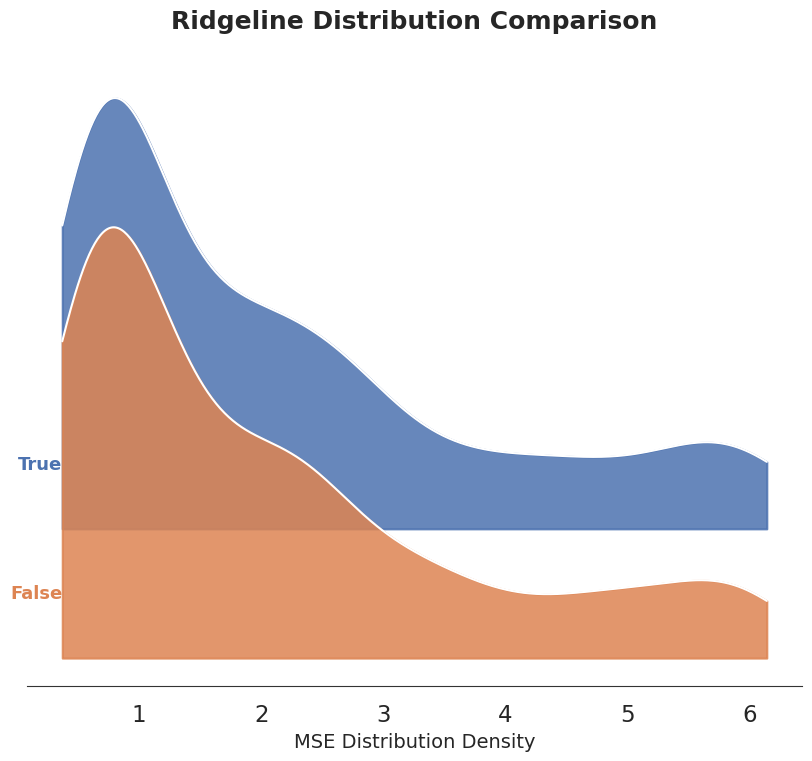

绘制ECDF图...


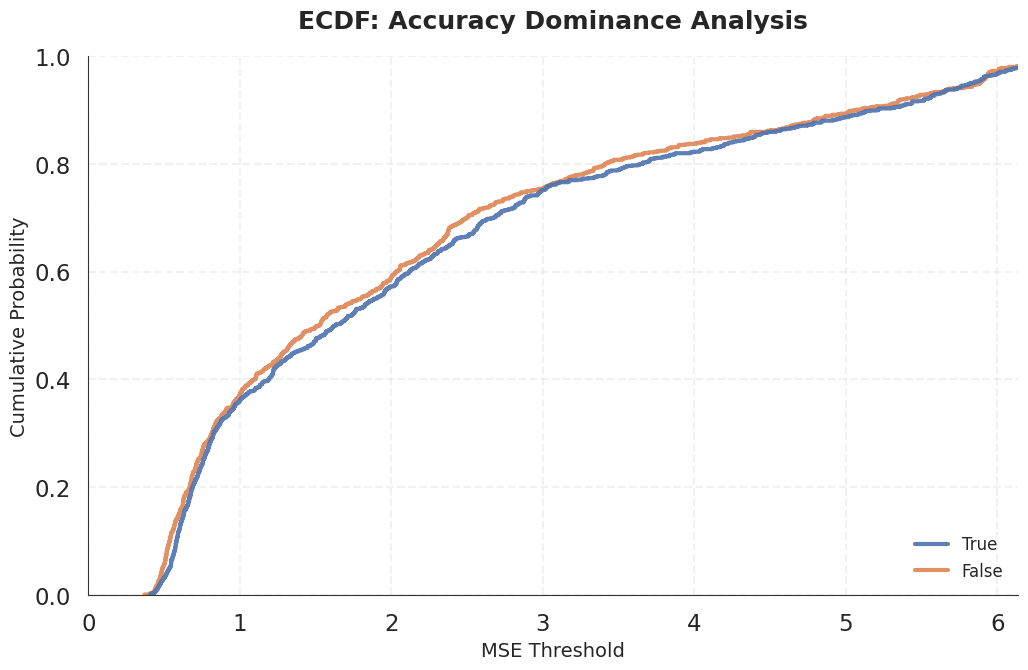

绘制箱线散点图...


/tmp/ipykernel_2642138/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


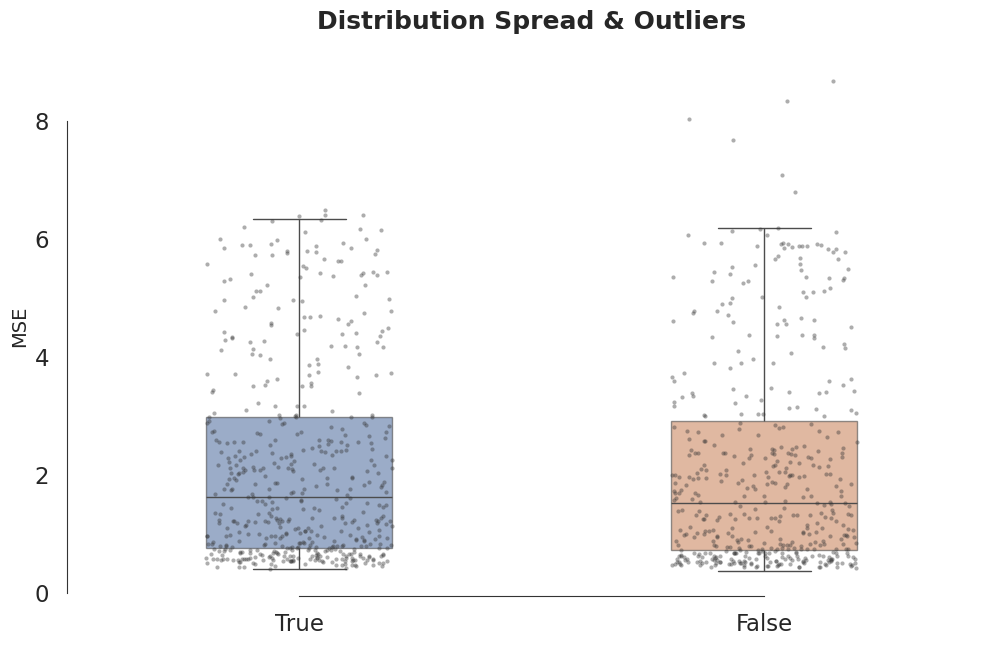

In [8]:
evaluator = ModelEvaluator(dict_seriessampling2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

        Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                 
DishTS   1095  3.3964  1.0877  1.6997  2.2813  3.0141   6.6799  1.6546
None      981  4.6773  2.2291  3.0344  3.8114  4.6740   7.1706  1.2785
RevIN    1111  1.4018  0.9586  1.0439  1.2047  1.3359   2.0308  0.3114
Stat     1351  1.4273  0.9588  1.0348  1.2108  1.3608   2.0743  0.3356
绘制手风琴图...


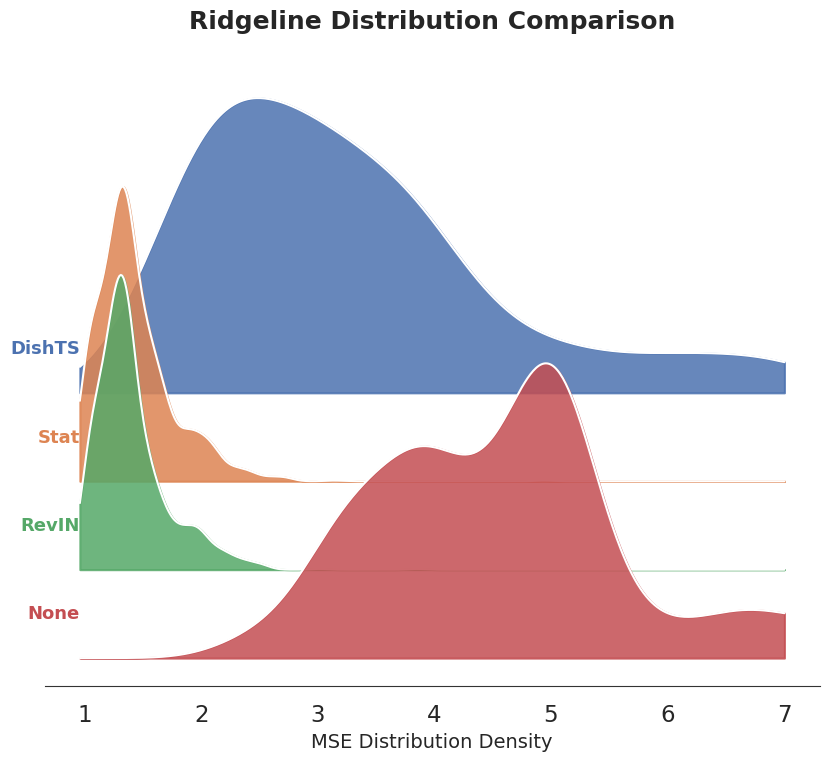

绘制ECDF图...


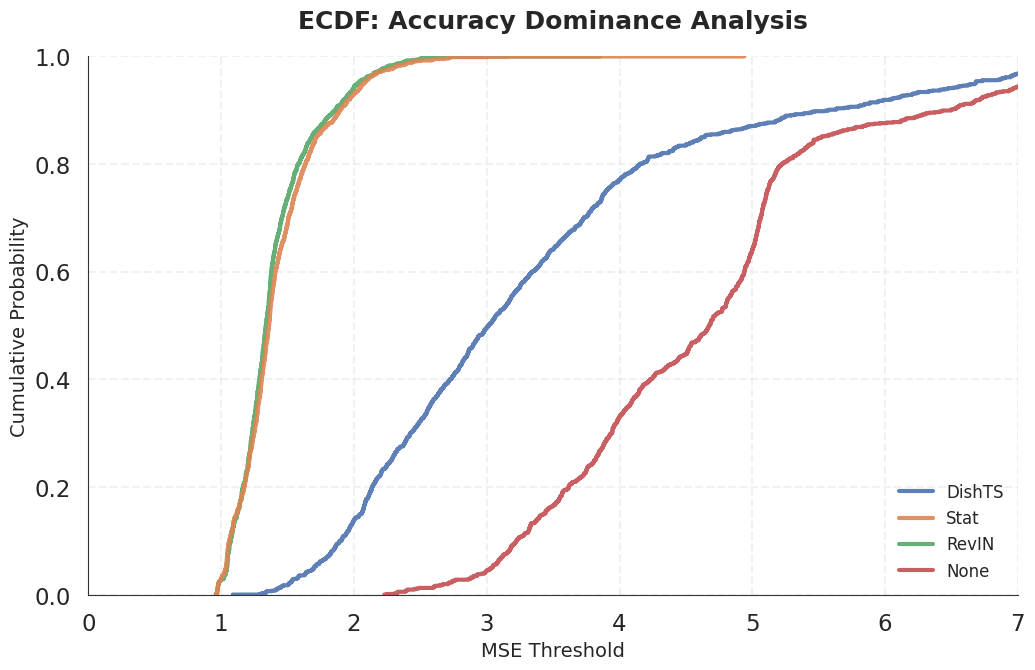

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


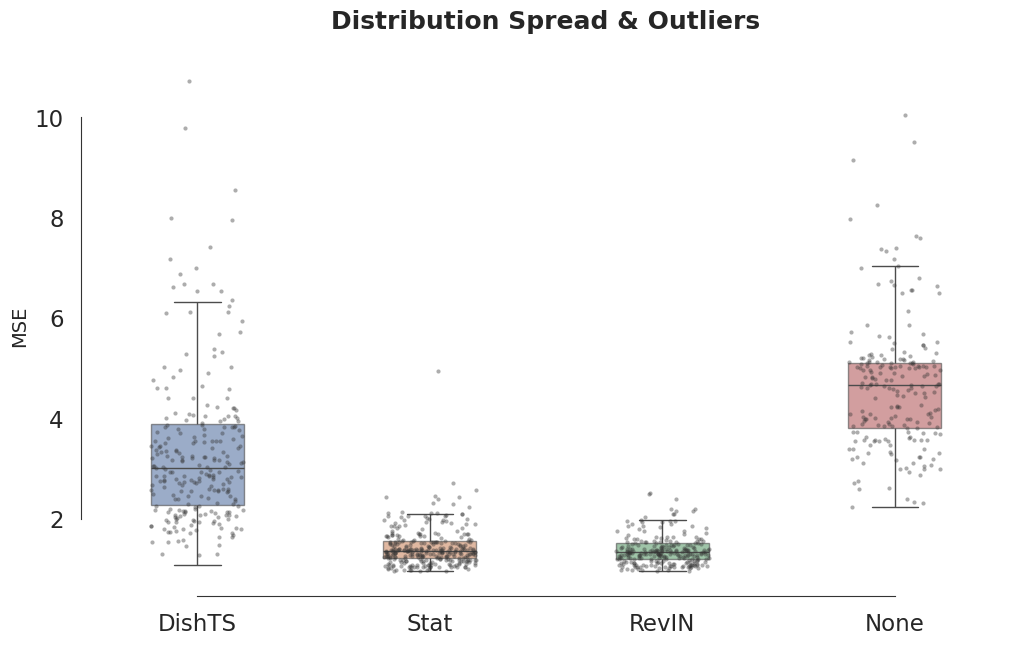

In [66]:
evaluator = ModelEvaluator(dict_seriesnorm2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

       Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                
DFT     1126  2.6028  0.9649  1.0581  1.3460  1.8346   5.6233  1.6778
MA      1101  2.5740  0.9586  1.0596  1.3026  1.8051   5.6041  1.7280
MoEMA   1147  2.6029  0.9667  1.0741  1.3109  1.8582   5.9382  1.6891
None    1164  2.6141  0.9643  1.0502  1.3595  1.8440   6.0262  1.7385
绘制手风琴图...


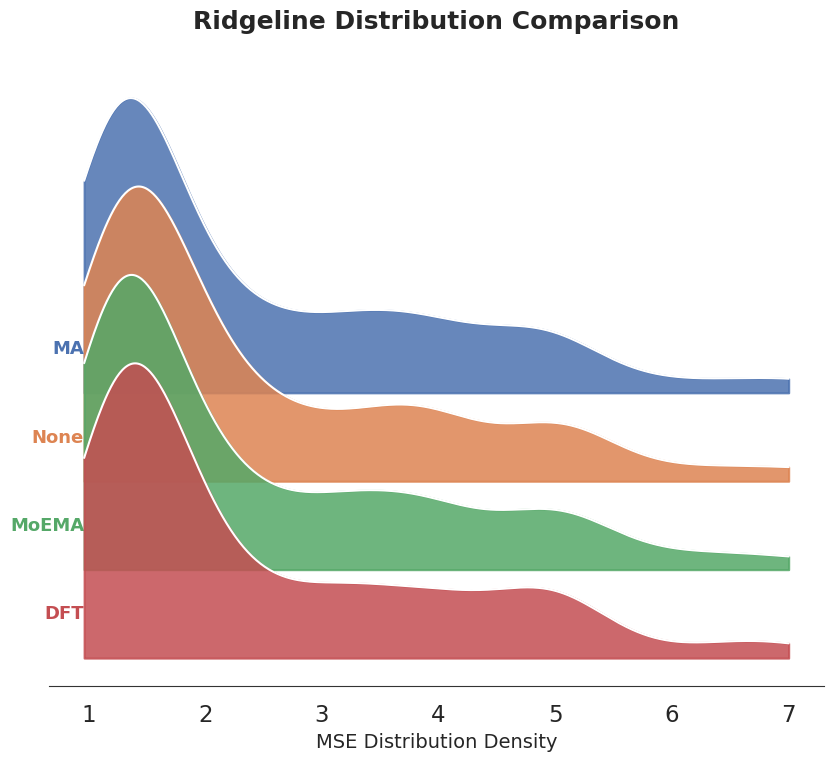

绘制ECDF图...


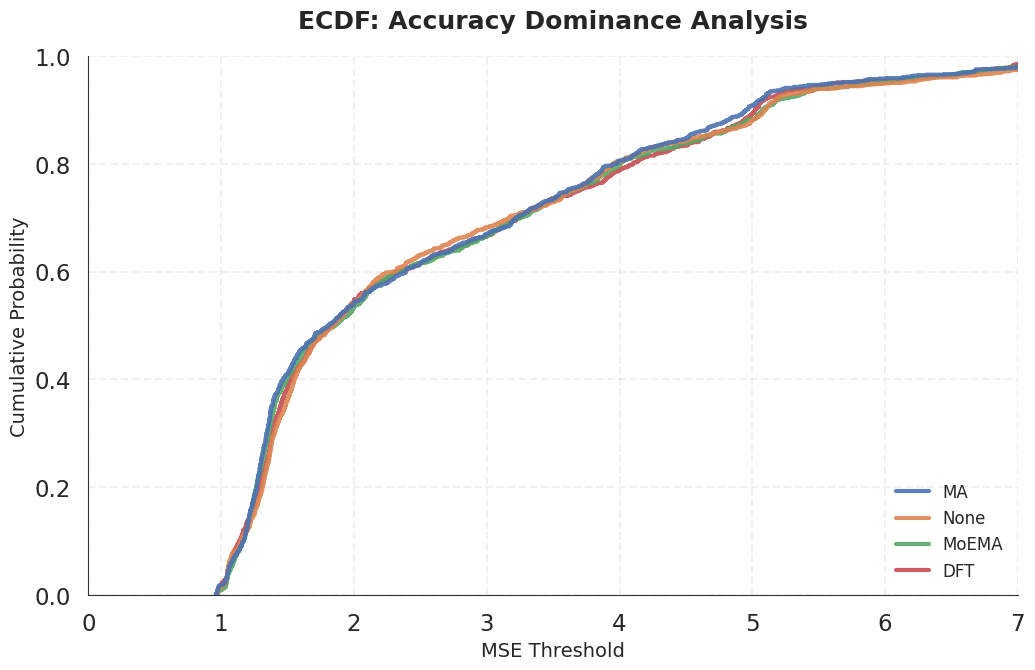

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


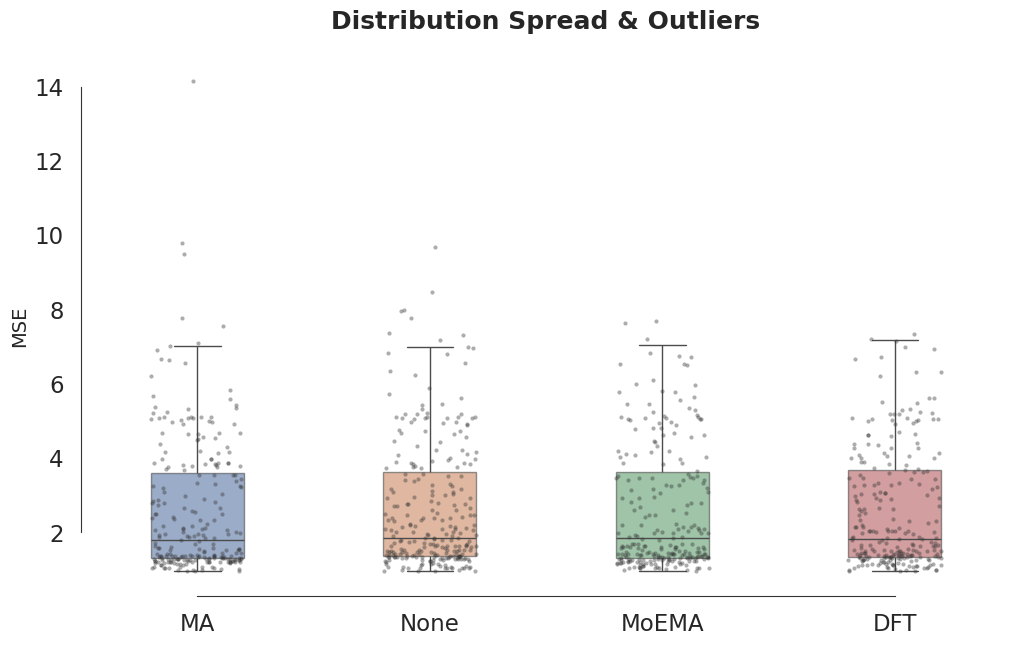

In [67]:
evaluator = ModelEvaluator(dict_seriesdecomp2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

       Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                
False   2959  2.6068  0.9643  1.0803  1.3347  1.8493   6.0526  1.6681
True    1579  2.5837  0.9586  1.0430  1.3153  1.8024   5.4609  1.7811
绘制手风琴图...


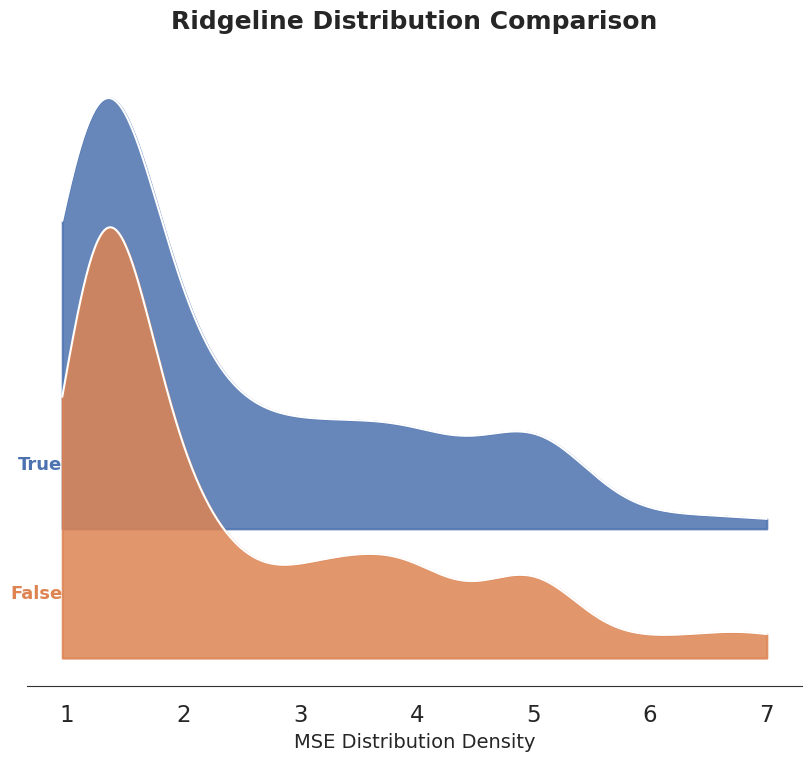

绘制ECDF图...


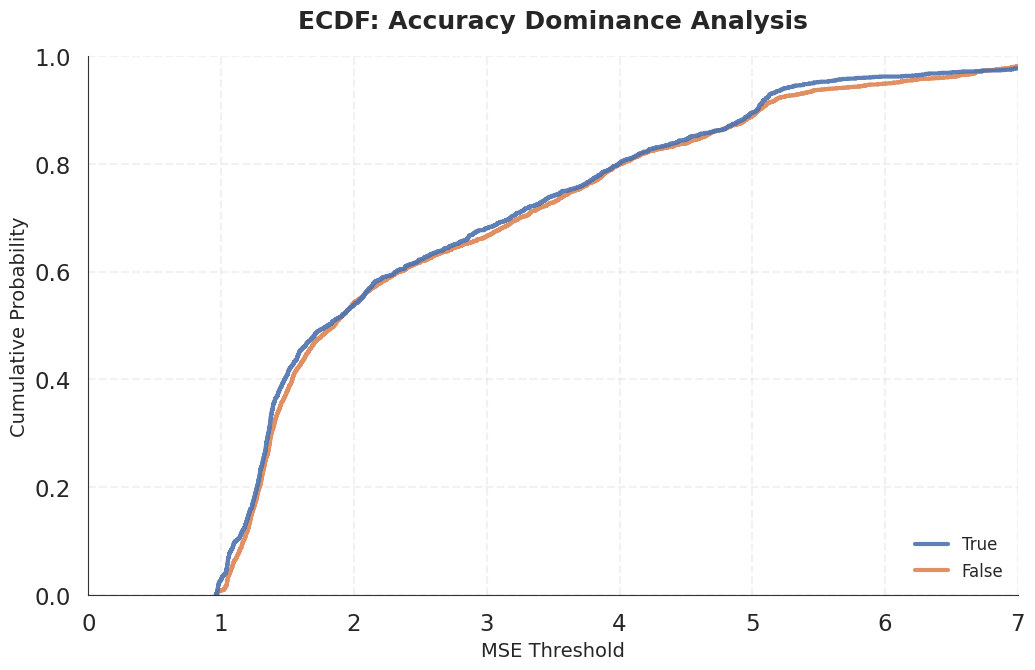

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


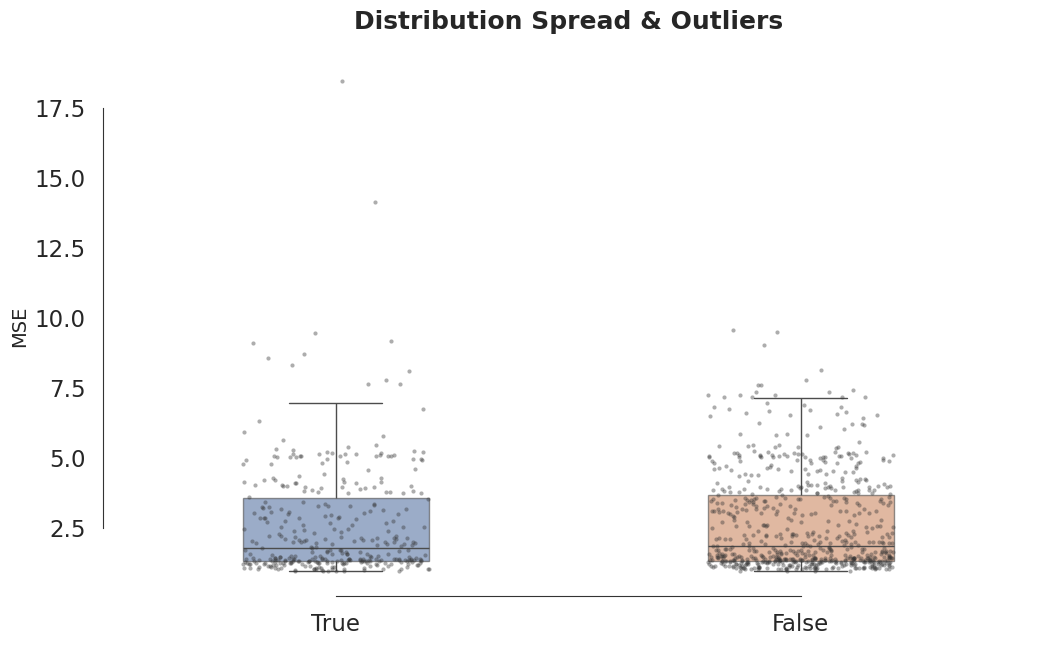

In [68]:
evaluator = ModelEvaluator(dict_channelindependent2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

                   Count    Mean    Best   Top_5  Top_25  Median  Risk_95  \
Model                                                                       
inverted-encoding    526  2.7242  0.9979  1.0950  1.3036  1.9832   6.3442   
series-encoding     3261  2.5657  0.9586  1.0487  1.3335  1.7956   5.4883   
series-patching      751  2.6545  0.9738  1.1475  1.3263  1.8729   6.3688   

                      Std  
Model                      
inverted-encoding  1.6875  
series-encoding    1.6786  
series-patching    1.8411  
绘制手风琴图...


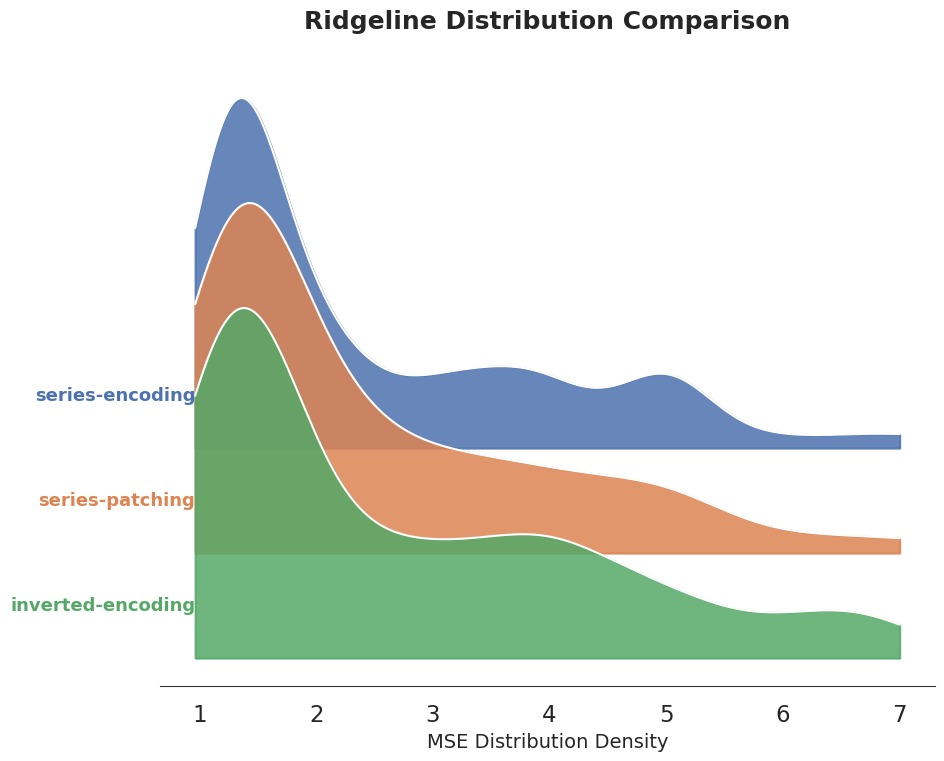

绘制ECDF图...


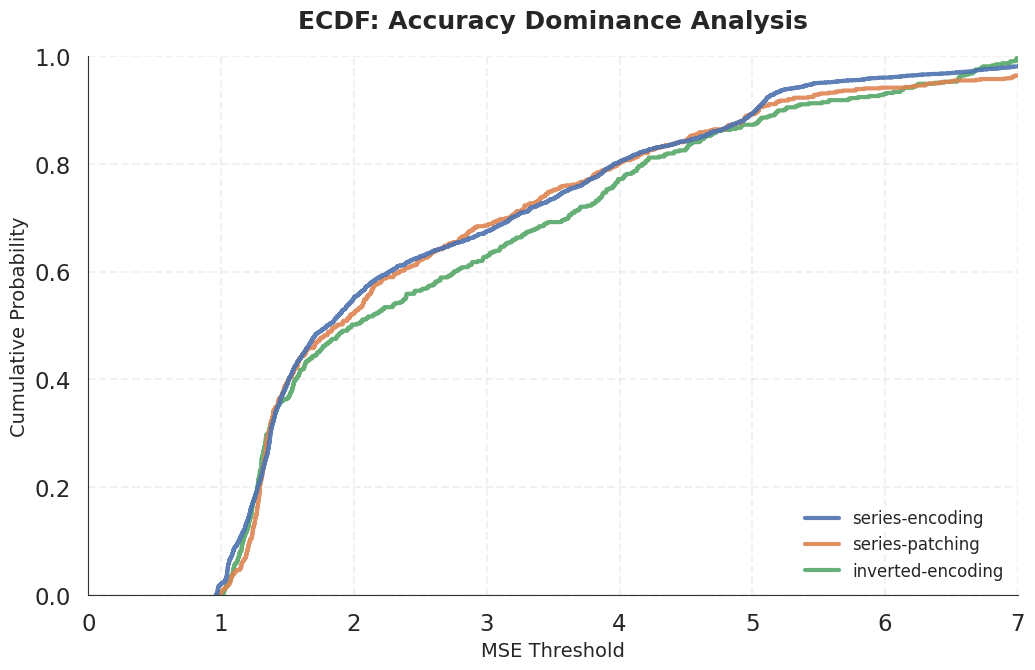

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


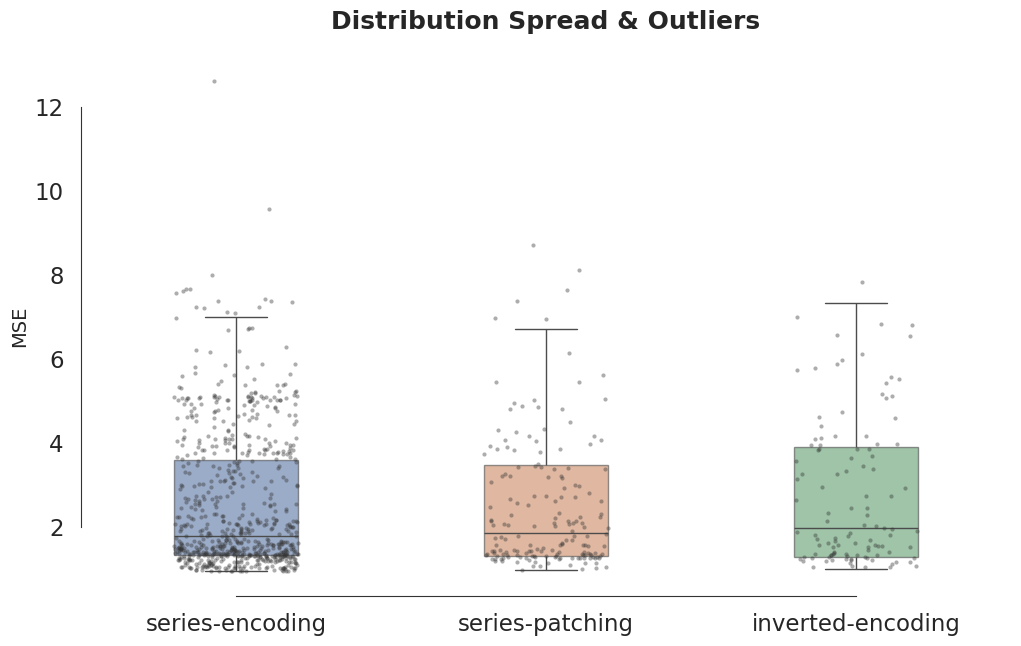

In [69]:
evaluator = ModelEvaluator(dict_inputembed2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

                              Count    Mean    Best   Top_5  Top_25  Median  \
Model                                                                         
auto-correlation                929  2.6500  0.9686  1.0818  1.3362  1.8868   
destationary-attention          212  1.4316  0.9697  1.0278  1.2442  1.3709   
frequency-enhanced-attention    991  2.5299  0.9623  1.0616  1.3255  1.8559   
self-attention                 1211  2.6858  0.9639  1.0607  1.3367  1.9636   
sparse-attention               1195  2.7349  0.9586  1.0526  1.3440  1.9385   

                              Risk_95     Std  
Model                                          
auto-correlation               5.6498  1.7580  
destationary-attention         2.0078  0.2960  
frequency-enhanced-attention   5.4480  1.6181  
self-attention                 5.8505  1.7025  
sparse-attention               6.2414  1.8129  
绘制手风琴图...


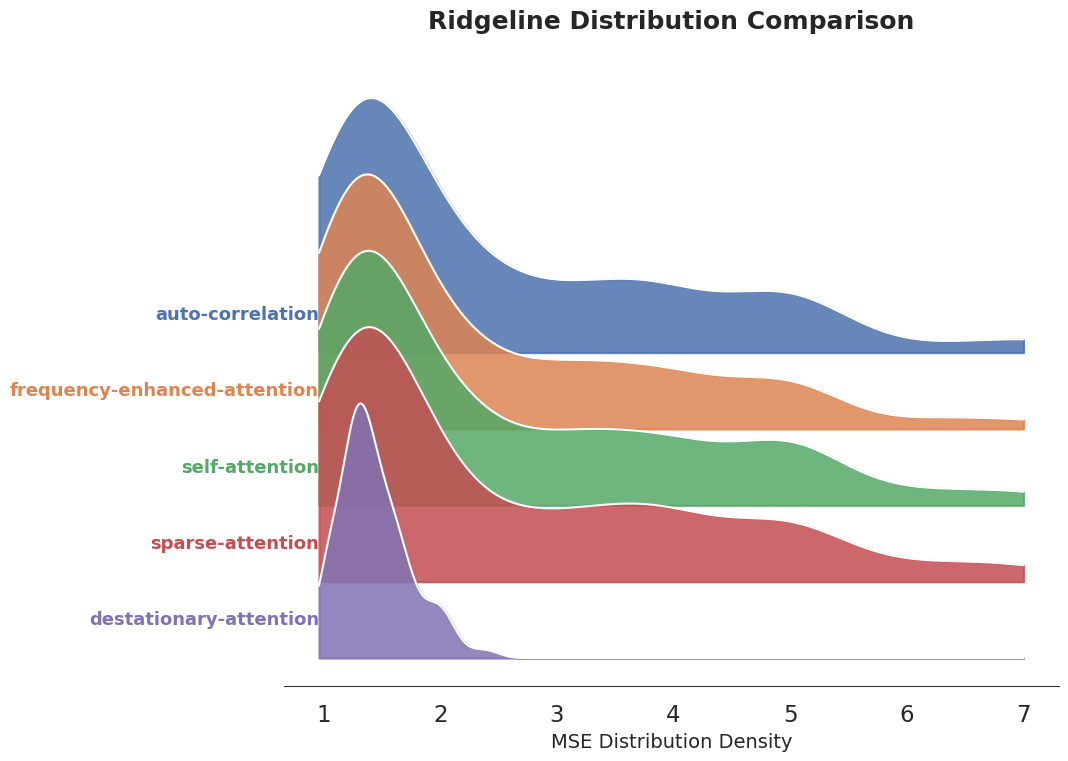

绘制ECDF图...


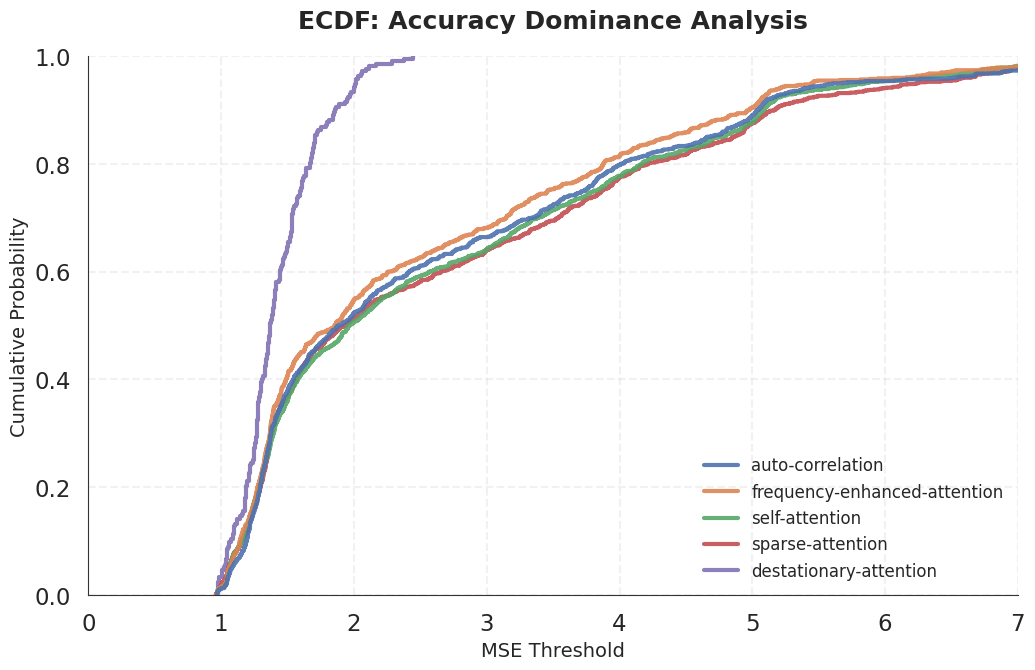

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


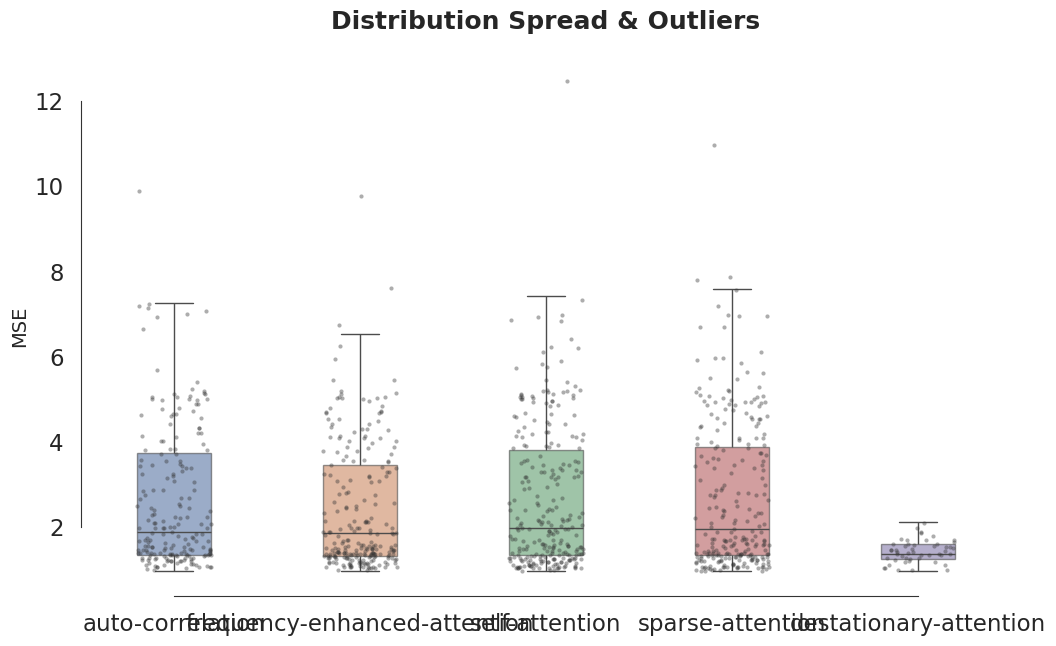

In [71]:
evaluator = ModelEvaluator(dict_attn2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

                  Count    Mean    Best   Top_5  Top_25  Median  Risk_95  \
Model                                                                      
null               2626  2.5773  0.9586  1.0431  1.3016  1.7694   5.4233   
self-attention      917  2.6108  1.0145  1.1763  1.3643  1.8652   6.5170   
sparse-attention    995  2.6443  0.9979  1.1182  1.3535  1.8977   6.2026   

                     Std  
Model                     
null              1.7475  
self-attention    1.6427  
sparse-attention  1.6621  
绘制手风琴图...


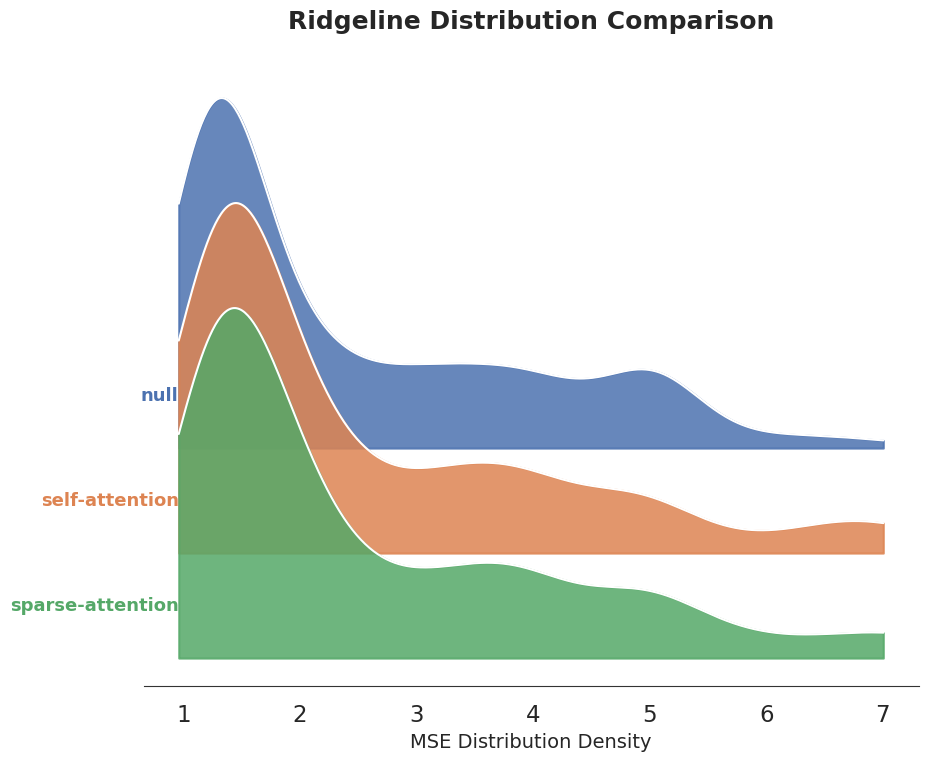

绘制ECDF图...


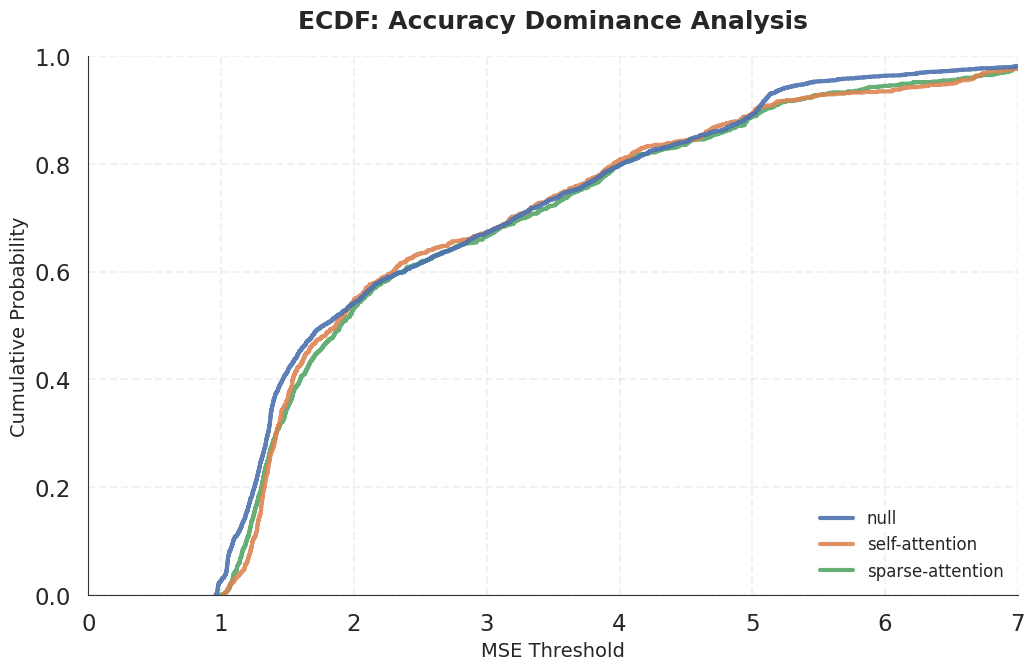

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


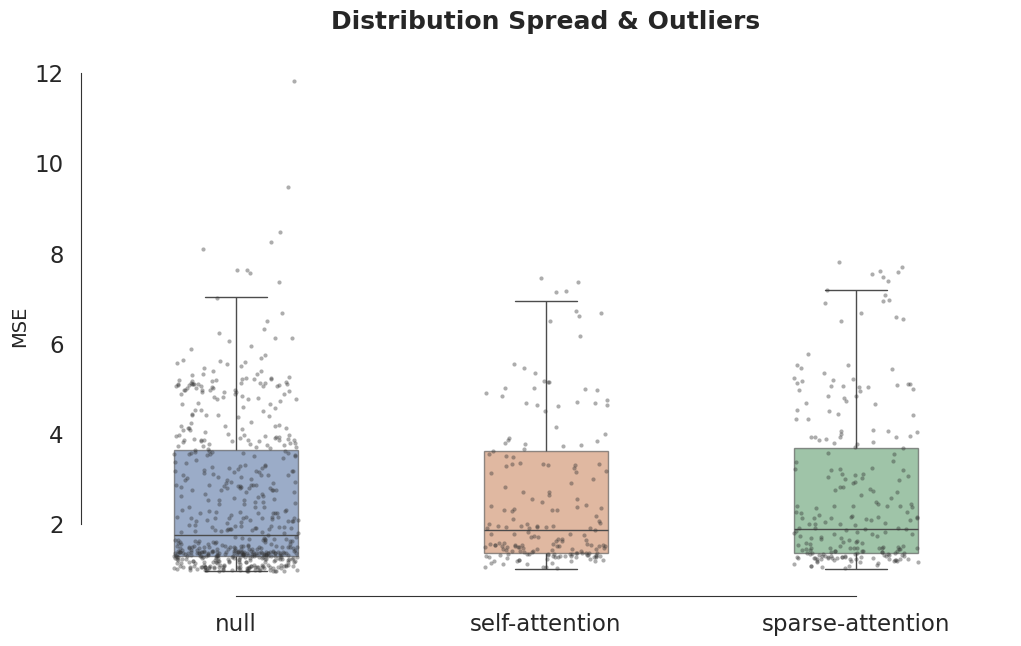

In [72]:
evaluator = ModelEvaluator(dict_featureattn2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

       Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                
sl192   1138  3.2184  0.9586  0.9826  1.2555  1.6976   7.4209  2.4807
sl48    1094  2.2472  0.9979  1.1978  1.3368  1.5365   4.4460  1.1335
sl512   1120  2.4208  1.0198  1.2206  1.5684  1.9990   5.0003  1.2117
sl96    1186  2.4965  1.0231  1.0482  1.2551  1.6555   5.0509  1.4736
绘制手风琴图...


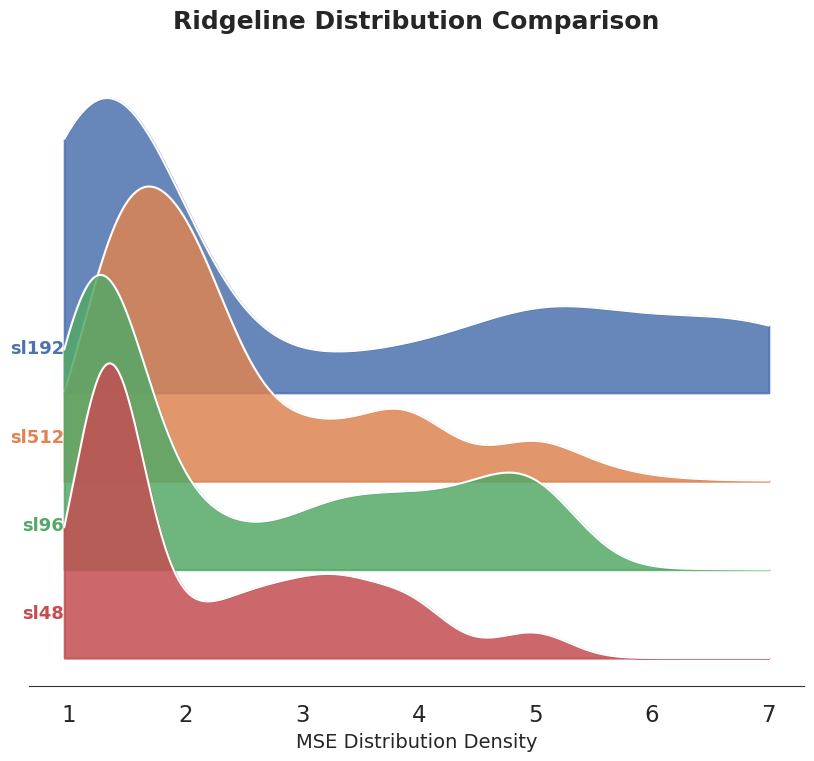

绘制ECDF图...


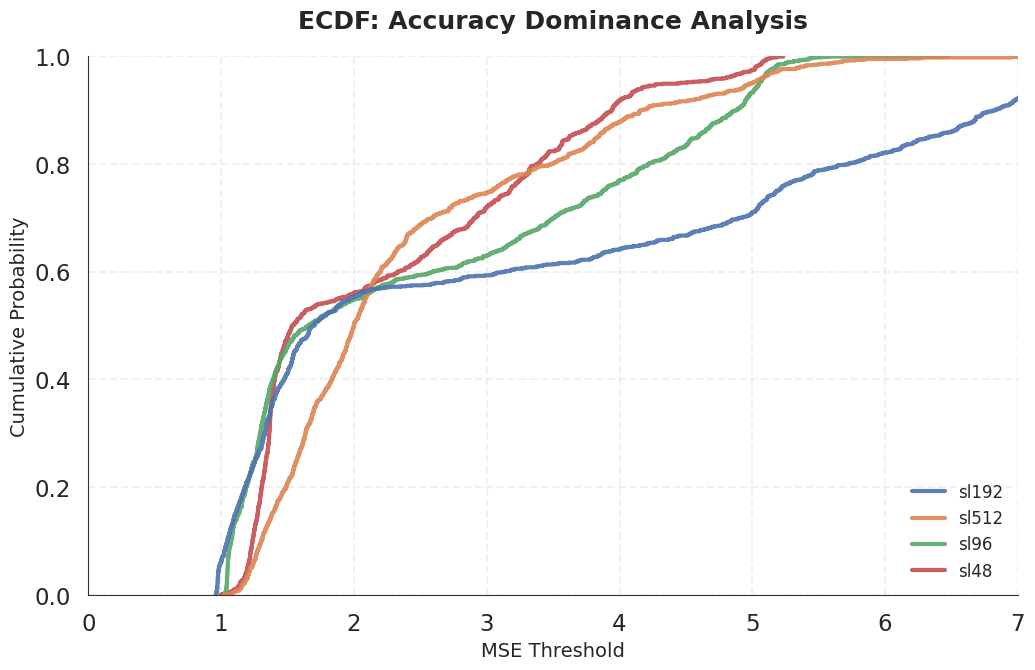

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


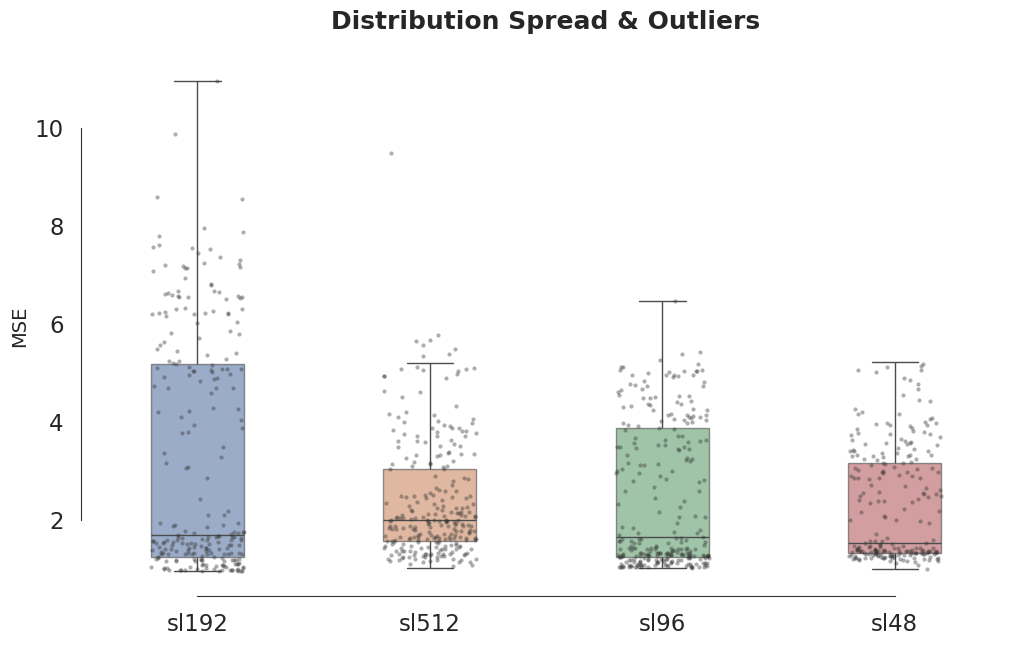

In [73]:
evaluator = ModelEvaluator(dict_seqlen2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()

             Count    Mean    Best   Top_5  Top_25  Median  Risk_95     Std
Model                                                                      
lfDBLoss       666  2.4805  0.9586  0.9811  1.2844  1.6814   5.7501  1.6538
lfFreDFLoss    619  2.2336  0.9644  1.0382  1.2358  1.4864   5.1136  1.4483
lfHUBER        621  2.7060  0.9954  1.2132  1.3928  1.9211   6.6739  1.7457
lfMAE          639  2.7406  0.9763  1.2175  1.4122  1.9801   6.0567  1.7171
lfMAPE         702  2.7819  0.9911  1.0709  1.3044  2.2700   5.1772  1.5503
lfMSE          637  2.5624  0.9742  1.1631  1.3111  1.6392   6.6496  1.8403
lfPSLoss       654  2.6632  0.9830  1.1434  1.3366  1.7565   6.7224  1.9067
绘制手风琴图...


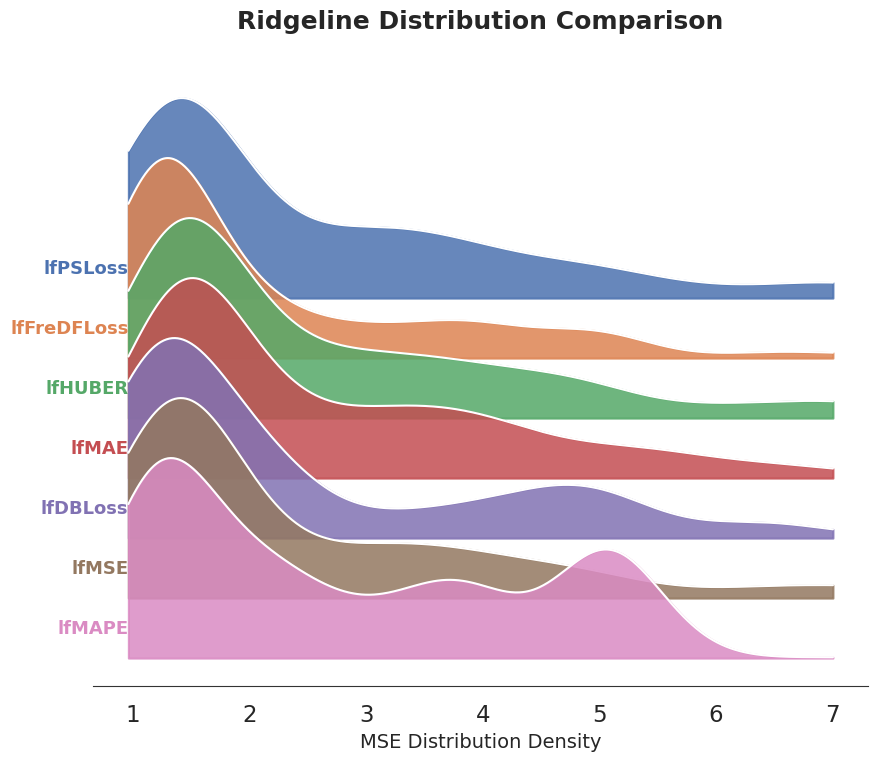

绘制ECDF图...


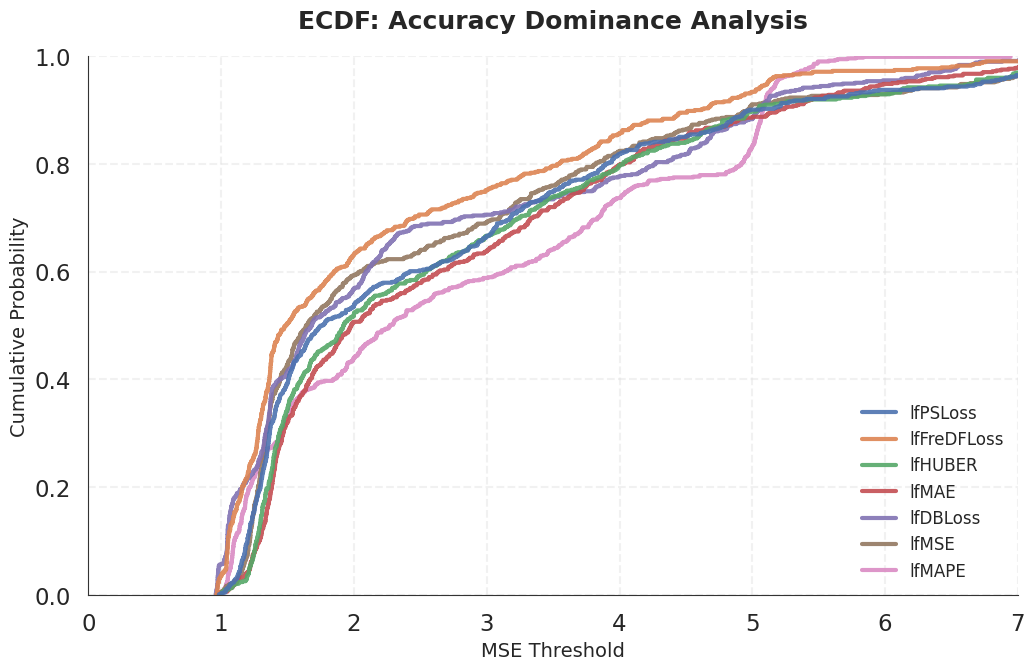

绘制箱线散点图...


/tmp/ipykernel_1925351/2893552038.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x='Model', y='MSE', palette=self.palette,


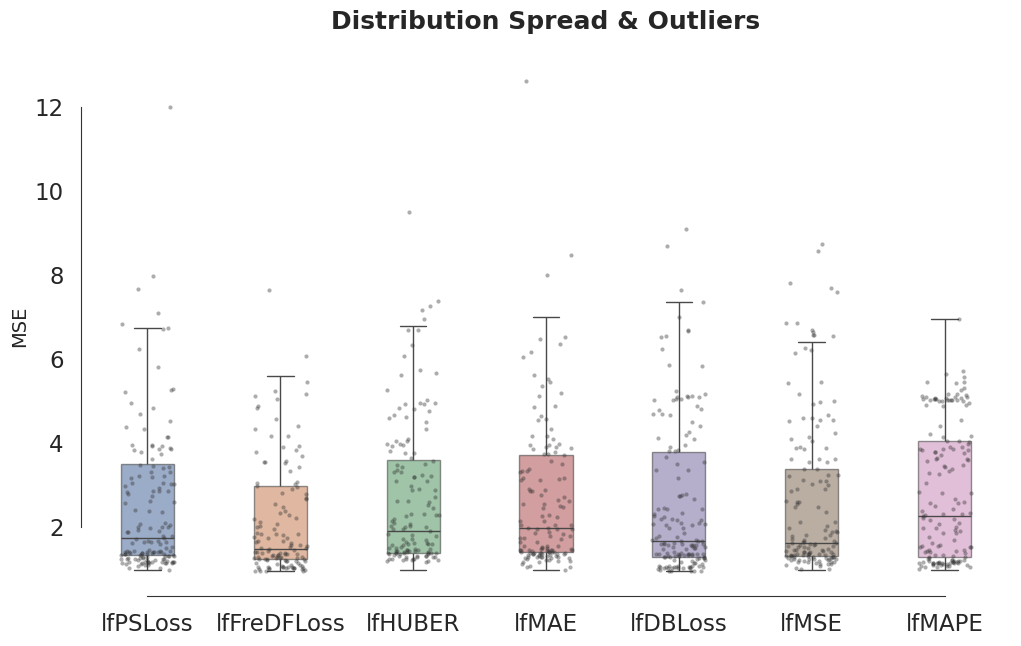

In [74]:
evaluator = ModelEvaluator(dict_lossfn2mse)

print(evaluator.stats)

print("绘制手风琴图...")
evaluator.plot_ridgeline()

print("绘制ECDF图...")
evaluator.plot_ecdf()

print("绘制箱线散点图...")
evaluator.plot_box_strip()